# Задание 10 (Контрольные вопросы)

**Тема**: Проверка статистических гипотез. Непараметрические критерии

In [1]:
# Подготовка зависимостей
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

### 1. Формулировка центральной предельной теоремы. Применение.

**Центральная предельная теорема (ЦПТ):** для любой генеральной совокупности со средним $\mu$ и среднеквадратичным отклонением $\sigma$ распределение выборочных средних выборок размера $n$ будет иметь среднее $\mu$ и среднеквадратичное отклонение $\frac{\sigma}{\sqrt{n}}$, а его форма будет стремиться к нормальной при $n$ стремящемся к бесконечности.

Распределение выборочных средних будет практически идеально нормальным, если:
- генеральная совокупность распределена нормально;
- в выборках 30 наблюдений или больше.

**Применение:** ЦПТ позволяет использовать вероятности распределения выборочных средних для проверки статистических гипотез. Зная, что распределение выборочных средних стремится к нормальному, мы можем оценивать вероятность получения той или иной выборки и делать выводы о генеральной совокупности. Именно эти вероятности используются для того, чтобы проверять гипотезы.

### 2. С помощью функции `stats.expon()` из модуля `scipy.stats` задать экспоненциальное распределение с параметром `scale=5`. С помощью метода `rvs()` для заданного распределения по 1000 раз смоделировать выборки объема: 10, 50, 100, 1000 элементов. Построить гистограмму средних для каждого объема выборки. Посчитать выборочные среднее, стандартное отклонение и коэффициент вариации для каждого объема выборки. Сделать соответствующие выводы.

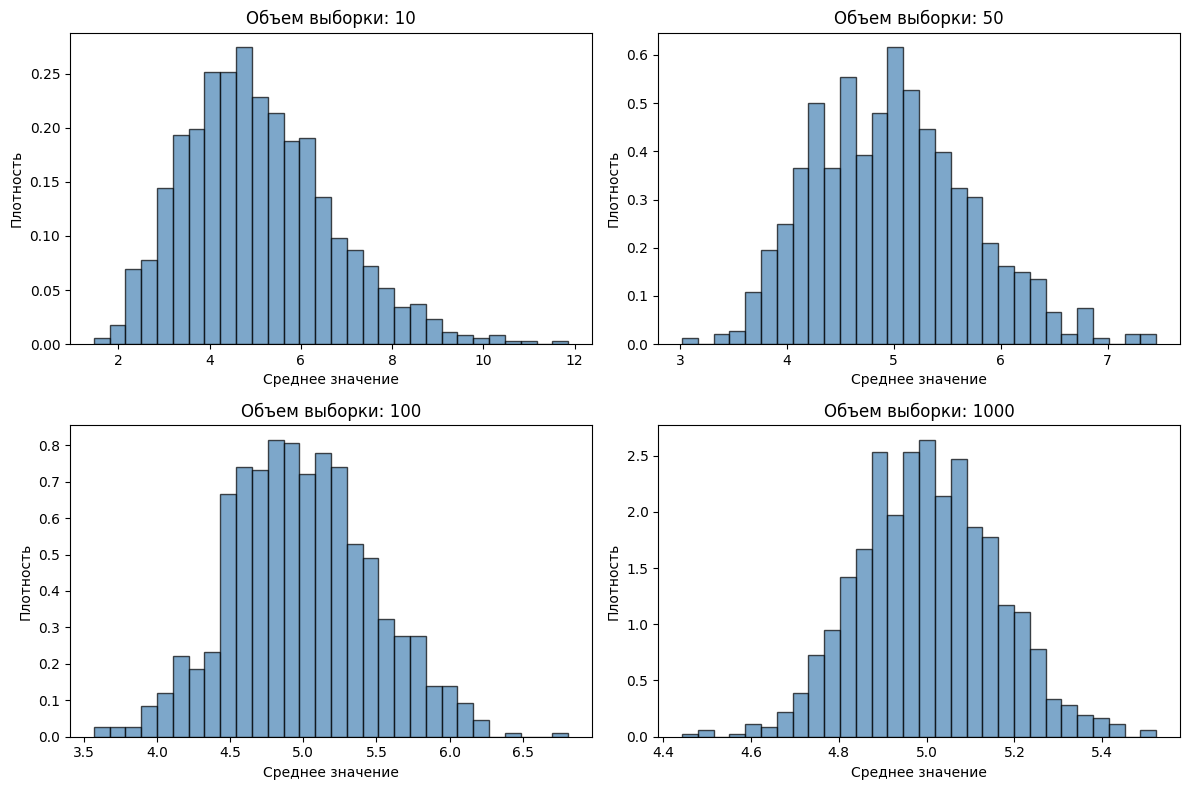

  Объем выборки |    Среднее |  Ст. откл. |  Коэф. вар., %
----------------------------------------------------------
             10 |       5.07 |       1.61 |          31.73
             50 |       4.99 |       0.73 |          14.67
            100 |       4.99 |       0.48 |           9.71
           1000 |       5.00 |       0.16 |           3.13

Вывод: с увеличением объёма выборки распределение выборочных средних становится всё более симметричным
и приближается к нормальному (в соответствии с ЦПТ). Стандартное отклонение и коэффициент вариации
уменьшаются при росте n — чем больше выборка, тем точнее среднее приближается к истинному значению (ЗБЧ).


In [2]:
scale_param = 5
sample_sizes = [10, 50, 100, 1000]
num_simulations = 1000

sample_means = {size: [] for size in sample_sizes}

for size in sample_sizes:
    for _ in range(num_simulations):
        sample = stats.expon(scale=scale_param).rvs(size)
        sample_means[size].append(np.mean(sample))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, size in enumerate(sample_sizes):
    axes[i].hist(
        sample_means[size],
        bins=30,
        alpha=0.7,
        color='steelblue',
        edgecolor='black',
        density=True
    )
    axes[i].set_title(f'Объем выборки: {size}')
    axes[i].set_xlabel('Среднее значение')
    axes[i].set_ylabel('Плотность')

plt.tight_layout()
plt.show()

print(f"{'Объем выборки':>15} | {'Среднее':>10} | {'Ст. откл.':>10} | {'Коэф. вар., %':>14}")
print('-' * 58)
for size in sample_sizes:
    means = np.array(sample_means[size])
    mean_val = np.mean(means)
    std_val = np.std(means, ddof=1)
    cv = (std_val / mean_val) * 100
    print(f"{size:>15} | {mean_val:>10.2f} | {std_val:>10.2f} | {cv:>14.2f}")

print()
print("Вывод: с увеличением объёма выборки распределение выборочных средних становится всё более симметричным")
print("и приближается к нормальному (в соответствии с ЦПТ). Стандартное отклонение и коэффициент вариации")
print("уменьшаются при росте n — чем больше выборка, тем точнее среднее приближается к истинному значению (ЗБЧ).")

### 3. Что такое гипотеза? Этапы тестирования гипотезы.

**Гипотеза** – предположение, которое не противоречит данным и для которого неизвестно, верно оно или нет.

**Этапы тестирования гипотезы:**

1. **Выдвижение гипотезы.** Мы выдвигаем гипотезу о значении неизвестного параметра генеральной совокупности. Гипотез у нас две — нулевая и альтернативная.
2. **Определение критериев проверки гипотезы.** Мы решаем, на основании каких критериев сможем отвергнуть нулевую гипотезу. В частности, выбирается уровень статистической значимости $\alpha$.
3. **Сбор данных и подсчет статистик.** Собираем выборку и вычисляем нужные статистики (например, среднее, z-оценку, критерий хи-квадрат).
4. **Подтверждение или опровержение.** Сравниваем полученное значение статистики с критической областью и делаем вывод об отвержении или не-отвержении нулевой гипотезы.

### 4. Нулевая и альтернативная гипотезы. Приведите примеры.

Формулировка **нулевой гипотезы** всегда предполагает отсутствие разницы или отсутствие изменений. Её обозначают как $H_0$ — гипотеза «нулевого эффекта».

**Альтернативная гипотеза** — это гипотеза о наличии эффекта. Она может быть направленная и ненаправленная — мы можем говорить как о конкретном изменении в определённую сторону, так и просто выдвигать гипотезу, что изменения есть и они отличны от 0.

**Пример из лекции (кофе и сессия):**
- $H_0$: $\mu = 175$ — в генеральной совокупности студентов среднее количество кофе, выпиваемого в сессию, такое же, как и в обычные дни учебного года.
- $H_1$: $\mu \neq 175$ — в генеральной совокупности студентов среднее количество кофе, выпиваемого в сессию, отличается от среднего количества, выпиваемого в течение года.

**Пример (IT-специалисты):**
- $H_0$: 50% всех IT-специалистов на топовых позициях — мужчины, и 50% — женщины (разницы нет).
- $H_1$: Распределение IT-специалистов на топовых позициях по полу отличается от 50%/50%.

### 5. Что такое уровень статистической значимости $\alpha$? Понятие и виды критических областей.

**Уровень статистической значимости $\alpha$** — вероятность получить очень маловероятную выборку (максимально отличную по своим характеристикам от генеральной совокупности). Уровень статистической значимости определяет границы **критической области** — области распределения, содержащей такие маловероятные выборки. Если статистика выборки (например, среднее) попадает в критическую область — нулевая гипотеза отвергается.

Выбирая уровень статистической значимости, мы выбираем степень уверенности, с которой будем утверждать, что нулевая гипотеза может быть отвергнута.

Если **альтернативная гипотеза ненаправленная**, то нас интересуют оба «хвоста» распределения — слева и справа от среднего (**двусторонняя критическая область**). Если **направленная** — мы смотрим только на тот «хвост», который соответствует направлению альтернативной гипотезы (**односторонняя критическая область**: левосторонняя или правосторонняя).

### 6. Типы ошибок при тестировании гипотез. Приведите практические примеры ошибок.

При тестировании гипотез выделяют два вида ошибок — ошибки 1-го или 2-го рода.

|                        | **Нет эффекта в реальности**, $H_0$ верна | **Есть эффект в реальности**, $H_0$ не верна |
|------------------------|-------------------------------------------|-----------------------------------------------|
| **Отвергаем $H_0$**    | Ошибка 1-го типа                          | Верное решение                                |
| **Не отвергаем $H_0$** | Верное решение                            | Ошибка 2-го типа                              |

**Ошибка первого типа** связана с тем, что мы отвергаем нулевую гипотезу, когда она на самом деле корректна. То есть мы утверждаем, что существует некоторый эффект, которого на самом деле нет. Эта ошибка напрямую связана со статистическим уровнем значимости $\alpha$.

**Пример ошибки первого типа:** мы проверяем, влияет ли новый метод обучения на успеваемость студентов. $H_0$: метод не влияет. Из-за неудачной выборки мы получили завышенные результаты и отвергли $H_0$, хотя на самом деле метод не даёт эффекта.

**Ошибка второго типа** связана с тем, что мы не отвергаем нулевую гипотезу, хотя на самом деле некоторая разница или взаимосвязь существует. Обозначается как $\beta$. Может быть связана с тем, что размер эффекта такой маленький, что его сложно зафиксировать на выборке небольшого размера.

**Пример ошибки второго типа:** мы проверяем, выпивают ли студенты в сессию больше кофе. $H_0$: количество кофе не изменилось. Из-за маленького размера выборки мы не смогли зафиксировать реально существующую разницу и не отвергли $H_0$, хотя эффект есть.

Ошибки $\alpha$ и $\beta$ взаимосвязаны: чем меньше ошибка $\alpha$, тем больше $\beta$. Для снижения $\alpha$ можно увеличить размер выборки.

### 7. Параметрические и непараметрические критерии проверки статистических гипотез: описание и применение.

Статистические критерии для проверки гипотез делятся на две больших категории — параметрические и непараметрические.

**Параметрические критерии** основываются на предположениях о некоторых характеристиках (параметрах) генеральных совокупностей. Например, предполагается, что данные в генеральной совокупности распределены нормально. Ещё одна особенность таких критериев — для их расчёта нужны количественные признаки.

**Непараметрические критерии** обычно не нуждаются в предположениях о параметрах генеральной совокупности или форме её распределения. Также подходят они и для работы с категориальными и номинальными признаками. Применяются в ситуациях, когда нарушены предпосылки параметрических критериев или сам тип признаков для таких тестов не годится.

Примером непараметрического критерия является критерий хи-квадрат — $\chi^2$, который используется для проверки гипотез о пропорциях распределений или наличии связи между признаками в генеральной совокупности.

### 8. Предпосылки использования критерия хи-квадрат для проверки статистических гипотез.

Предпосылки, при которых мы можем использовать критерий хи-квадрат для проверки статистических гипотез:

- Наблюдения должны быть независимы (например, каждый объект в наших данных должен присутствовать ровно один раз).
- Ожидаемые частоты для каждой из категорий не должны быть меньше 5.
- В целом рекомендуется использовать такой тест для выборок, в которых не меньше 100 наблюдений.

### 9. Критерий согласия хи-квадрат: назначение и свой пример использования с расчётом в Python.

С помощью **критерия согласия хи-квадрат (критерий согласия Пирсона)** мы на основании выборки проверяем гипотезу о форме или пропорциях распределения генеральной совокупности. Этот статистический тест определяет, насколько распределение выборки близко к форме или пропорциям распределения, описанного в нулевой гипотезе.

Критерий согласия хи-квадрат можно рассчитать с помощью функции `chisquare()` библиотеки `scipy.stats`.

**Пример:** Предположим, мы опросили 300 студентов об их предпочтениях по специализациям (A, B, C) и хотим проверить, что студенты выбирают специализации равномерно.
- $H_0$: Каждую специализацию выбирают одинаково часто (по 33.3%).
- $H_1$: Распределение выборов отличается от равномерного.
- Уровень значимости: $\alpha = 0.05$.

In [3]:
import scipy.stats as stats
import numpy as np

# Наблюдаемые частоты: специализация A, B, C
observed = np.array([130, 100, 70])
n = observed.sum()

# Ожидаемые частоты при равномерном распределении (H0: по 1/3 каждая)
expected = np.array([n / 3, n / 3, n / 3])

chi2_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f"Наблюдаемые частоты: {observed}")
print(f"Ожидаемые частоты:   {expected}")
print(f"Значение критерия хи-квадрат: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print()
alpha = 0.05
if p_value < alpha:
    print(f"P-value ({p_value:.4f}) < alpha ({alpha}): нулевая гипотеза отвергается.")
    print("Распределение по специализациям статистически значимо отличается от равномерного.")
else:
    print(f"P-value ({p_value:.4f}) >= alpha ({alpha}): оснований отвергнуть нулевую гипотезу нет.")

Наблюдаемые частоты: [130 100  70]
Ожидаемые частоты:   [100. 100. 100.]
Значение критерия хи-квадрат: 18.0000
P-value: 0.0001

P-value (0.0001) < alpha (0.05): нулевая гипотеза отвергается.
Распределение по специализациям статистически значимо отличается от равномерного.


### 10. Что такое число степеней свободы? Формула расчёта.

**Число степеней свободы** ($df$ — degrees of freedom) — количество значений в итоговом вычислении статистики, способных варьироваться. При разном значении степеней свободы меняется форма распределения статистик хи-квадрат, а значит и значения критерия, отсекающие определённую пропорцию распределения, будут варьироваться.

**Формула для критерия согласия хи-квадрат:**
$$df = C - 1$$
где $C$ — количество колонок в таблице (категорий).

**Формула для критерия независимости хи-квадрат:**
$$df = (R - 1) \cdot (C - 1)$$
где $R$ и $C$ — количество рядов и колонок в таблице сопряженности соответственно.

### 11. Что такое p-value?

**P-value** – это минимальный уровень значимости, на котором нулевая гипотеза может быть отвергнута. Соответственно, если p-value меньше нашего фиксированного уровня значимости, на котором мы проверяем гипотезу, то нулевую гипотезу следует отвергнуть, если более — то отвергать нулевую гипотезу оснований нет.

P-value – это вероятность того, что нулевая гипотеза жизнеспособна, чем выше p-value, тем лучше, если мы хотим, чтобы нулевая гипотеза не была отвергнута.

**Важно:** в выводе относительно отвержения / не-отвержения нулевой гипотезы необходимо указывать уровень значимости, так как от этого зависит результат. Так, например, в случае, если p-value равно 0.02, у нас есть основания отвергнуть нулевую гипотезу на уровне значимости 5% (0.02 < 0.05), и нет оснований отвергнуть её на уровне значимости 1% (0.02 > 0.01).

### 12. Критерий независимости хи-квадрат: назначение и свой пример использования с расчётом в Python.

С помощью **критерия независимости хи-квадрат (критерий независимости Пирсона)** мы на основании выборки проверяем наличие зависимости между двумя признаками в генеральной совокупности. Каждое наблюдение в выборке принадлежит к одной из категорий обоих интересующих нас признаков, что позволяет упорядочить данные в виде таблицы сопряженности. Распределение частот принадлежности к категориям в выборке используется для того, чтобы протестировать гипотезы о распределении частот в генеральной совокупности.

Нулевая гипотеза говорит, что между двумя переменными отсутствует зависимость.

Критерий независимости хи-квадрат можно рассчитать с помощью функции `chi2_contingency()` библиотеки `scipy.stats`.

**Пример:** Проверим, существует ли зависимость между уровнем образования (среднее / высшее) и предпочтением способа чтения (бумажная книга / электронная книга) у 200 опрошенных.
- $H_0$: В генеральной совокупности зависимости между уровнем образования и предпочтением способа чтения нет.
- $H_1$: В генеральной совокупности зависимость между уровнем образования и предпочтением способа чтения существует.
- Уровень значимости: $\alpha = 0.05$.

In [4]:
import scipy.stats as stats
import numpy as np
import pandas as pd

# Таблица сопряженности наблюдаемых частот
# Строки: среднее образование, высшее образование
# Столбцы: бумажная книга, электронная книга
observed = np.array([
    [70, 30],   # среднее образование
    [40, 60]    # высшее образование
])

ct = pd.DataFrame(
    observed,
    index=['Среднее образование', 'Высшее образование'],
    columns=['Бумажная книга', 'Электронная книга']
)
print("Таблица сопряженности (наблюдаемые частоты):")
print(ct)
print()

chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed, correction=False)

print(f"Значение критерия хи-квадрат: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Степени свободы: {dof}")
print()
print("Ожидаемые частоты:")
print(pd.DataFrame(
    expected,
    index=['Среднее образование', 'Высшее образование'],
    columns=['Бумажная книга', 'Электронная книга']
).round(2))
print()
alpha = 0.05
if p_value < alpha:
    print(f"P-value ({p_value:.4f}) < alpha ({alpha}): нулевая гипотеза отвергается.")
    print("В генеральной совокупности зависимость между уровнем образования и способом чтения существует.")
else:
    print(f"P-value ({p_value:.4f}) >= alpha ({alpha}): оснований отвергнуть нулевую гипотезу нет.")

Таблица сопряженности (наблюдаемые частоты):
                     Бумажная книга  Электронная книга
Среднее образование              70                 30
Высшее образование               40                 60

Значение критерия хи-квадрат: 18.1818
P-value: 0.0000
Степени свободы: 1

Ожидаемые частоты:
                     Бумажная книга  Электронная книга
Среднее образование            55.0               45.0
Высшее образование             55.0               45.0

P-value (0.0000) < alpha (0.05): нулевая гипотеза отвергается.
В генеральной совокупности зависимость между уровнем образования и способом чтения существует.


In [5]:
# Экспорт в HTML
__import__("subprocess").run([
    "jupyter",
    "nbconvert",
    "--to",
    "html",
    __vsc_ipynb_file__.split("/")[-1]
])

[NbConvertApp] Converting notebook lection10.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 391377 bytes to lection10.html


CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'lection10.ipynb'], returncode=0)